In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report, RocCurveDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

In [ ]:
# load the classification data set (generated from the NB 1 )
data = pd.read_csv('/content/drive/MyDrive/IIT/level 05/ML/Coursework/w2119725/classification_data_set.csv')
data.head()

,age,income,home_ownership,employment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status
0,40.0,182004,3,3,1,35000,8.00,0.19,0,11,0
1,40.0,90000,0,3,2,35000,12.42,0.39,0,14,0
2,40.0,131004,0,9,5,30000,7.90,0.23,0,13,0
3,40.0,150000,0,9,0,25000,11.89,0.17,0,11,0
4,40.0,132000,0,3,2,25000,16.82,0.22,0,17,0


Define X and Y

In [ ]:
# seperate x and y
x = data.drop(columns=['loan_approval_status'])
y = data['loan_approval_status']

In [ ]:
# checkt x columns
list(x.columns)

['age',
 'income',
 'home_ownership',
 'employment_length',
 'loan_intent',
 'loan_amount',
 'loan_interest_rate',
 'loan_income_ratio',
 'payment_default_on_file',
 'credit_history_length']

In [ ]:
print("X shape:", x.shape)
print("y shape:", y.shape)

X shape: (53033, 10)
y shape: (53033,)


In [ ]:
# seperate x, y columns for the tarining and testing
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42, stratify=y
)

In [ ]:
# check the x train set and test set shapes
print("x train instances: ", x_train.shape)
print("x test instances: ", x_test.shape)

x train instances:  (37123, 10)
x test instances:  (15910, 10)


In [ ]:
# Initialise the MinMaxScaler
scaler = MinMaxScaler()

# Fit the scaler on training data ONLY, then transform both train and test
# This prevents information from the test set leaking into the model (data leakage)
x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train), columns=x_train.columns)
x_test_scaled  = pd.DataFrame(scaler.transform(x_test),      columns=x_test.columns)

# Confirm the scaled shapes match the originals
print("Scaled x_train shape:", x_train_scaled.shape)
print("Scaled x_test shape: ", x_test_scaled.shape)

Scaled x_train shape: (37123, 10)
Scaled x_test shape:  (15910, 10)


In [56]:
x_train_scaled

,age,income,home_ownership,employment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length
0,0.20,0.068006,1.0,0.071429,0.0,0.072464,0.416556,0.085366,0.0,0.000000
1,0.35,0.075734,1.0,0.071429,1.0,0.130435,0.435099,0.146341,0.0,0.333333
2,0.20,0.073158,0.0,0.000000,0.4,0.188406,0.366887,0.219512,0.0,0.066667
3,0.60,0.104070,1.0,0.142857,1.0,0.159420,0.484106,0.134146,0.0,0.466667
4,0.60,0.194230,1.0,0.285714,0.8,0.333333,0.123841,0.158537,0.0,0.533333
...,...,...,...,...,...,...,...,...,...,...
37118,0.25,0.129830,1.0,0.214286,0.4,0.333333,0.470861,0.231707,1.0,0.000000
37119,0.25,0.190366,0.0,0.642857,0.4,0.275362,0.123841,0.134146,0.0,0.066667
37120,0.10,0.168470,1.0,0.000000,0.2,0.420290,0.368874,0.231707,0.0,0.000000
37121,0.10,0.052550,1.0,0.214286,0.2,0.217391,0.099338,0.317073,0.0,0.066667


In [ ]:
# Navie bayes modelling
nb_model = GaussianNB()
nb_model.fit(x_train, y_train)
y_nb_pred = nb_model.predict(x_test)

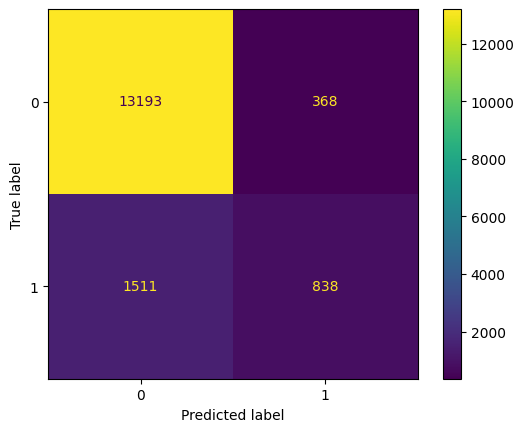

In [ ]:
# navie bayes cofusion matrix
cm_nb = confusion_matrix(y_test, y_nb_pred)
display_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb)
display_nb.plot()

In [ ]:
# navie bayes classification report
print("Navie Bayes classification report: ", classification_report(y_test, y_nb_pred))

Navie Bayes classification report:                precision    recall  f1-score   support

           0       0.90      0.97      0.93     13561
           1       0.69      0.36      0.47      2349

    accuracy                           0.88     15910
   macro avg       0.80      0.66      0.70     15910
weighted avg       0.87      0.88      0.87     15910



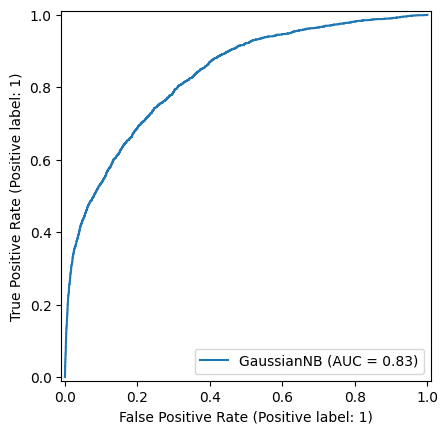

In [ ]:
# navie bayes ROC curve
nb_roc = RocCurveDisplay.from_estimator(nb_model, x_test, y_test)

In [ ]:
# Logistic Regression  modelling
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(x_train_scaled, y_train)

# Predict loan approval status on SCALED test data
y_lr_pred = lr_model.predict(x_test_scaled)

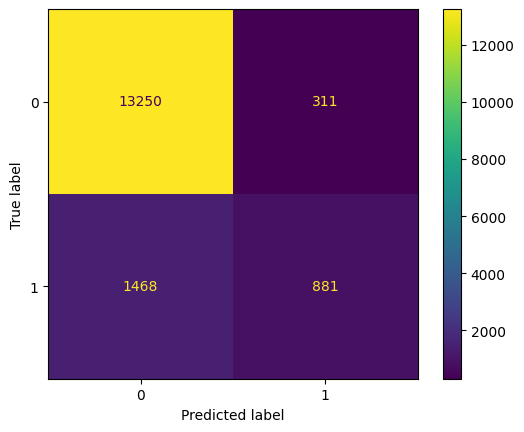

In [ ]:
# Logistic Regression (LR) confusion matrix
cm_lr = confusion_matrix(y_test, y_lr_pred)
display_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
display_lr.plot()

In [ ]:
# LR classification report
print("Logistic Regression Classification Report: ", classification_report(y_test, y_lr_pred))

Logistic Regression Classification Report:                precision    recall  f1-score   support

           0       0.90      0.98      0.94     13561
           1       0.74      0.38      0.50      2349

    accuracy                           0.89     15910
   macro avg       0.82      0.68      0.72     15910
weighted avg       0.88      0.89      0.87     15910



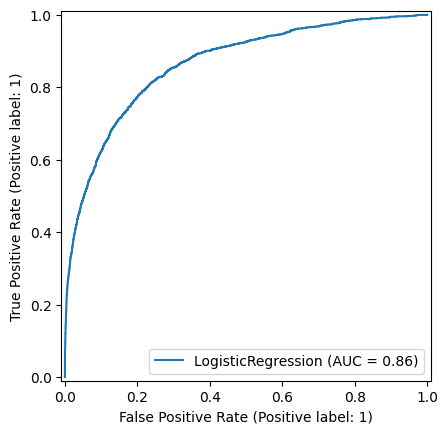

In [ ]:
# LR ROC curve
lr_roc = RocCurveDisplay.from_estimator(lr_model, x_test_scaled, y_test)

KNN Model

In [ ]:
# KNeighboures modelling
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train_scaled, y_train)
y_knn_pred = knn_model.predict(x_test_scaled)

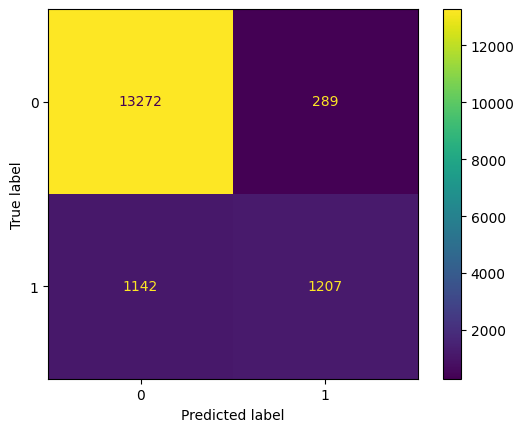

In [ ]:
cm_knn = confusion_matrix(y_test, y_knn_pred)
display_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn)
display_knn.plot()

In [ ]:
# KNN classification report
print("KNN classification report: ", classification_report(y_test, y_knn_pred))

KNN classification report:                precision    recall  f1-score   support

           0       0.92      0.98      0.95     13561
           1       0.81      0.51      0.63      2349

    accuracy                           0.91     15910
   macro avg       0.86      0.75      0.79     15910
weighted avg       0.90      0.91      0.90     15910



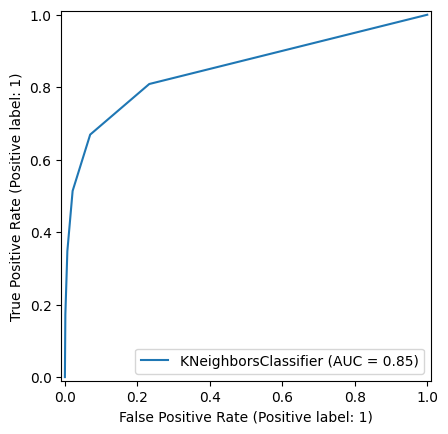

In [ ]:
knn_roc = RocCurveDisplay.from_estimator(knn_model, x_test_scaled, y_test)

In [ ]:
print("Accuracy Scores:")
print("NB  :", metrics.accuracy_score(y_test, y_nb_pred))
print("LR  :", metrics.accuracy_score(y_test, y_lr_pred))
print("KNN :", metrics.accuracy_score(y_test, y_knn_pred))

Accuracy Scores:
NB  : 0.8818981772470145
LR  : 0.8881835323695789
KNN : 0.910056568196103


Hyperparameter Tuning with KNN (GridSearchCV)

In [ ]:
param_grid = {
    'n_neighbors': np.arange(1, 25),
    'metric': ['euclidean', 'manhattan']
}

knn_gscv = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='roc_auc')
knn_gscv.fit(x_train_scaled, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24])},
             scoring='roc_auc')

In [ ]:
print("Best parameters: ", knn_gscv.best_params_)

Best parameters:  {'metric': 'manhattan', 'n_neighbors': np.int64(24)}


In [ ]:
y_pred_tuned = knn_gscv.predict(x_test_scaled)

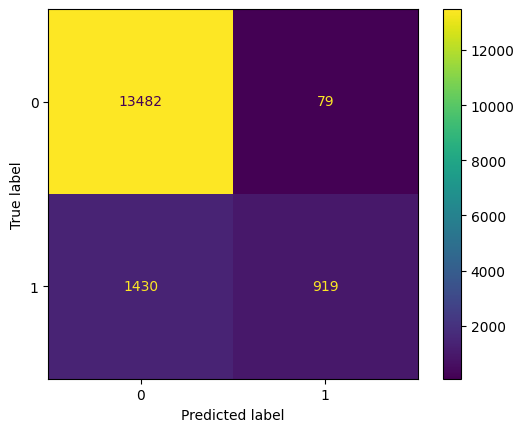

In [ ]:
cm_knn_gscv = confusion_matrix(y_test, y_pred_tuned, labels=knn_gscv.classes_)
disp_knn_gscv_cm = ConfusionMatrixDisplay(cm_knn_gscv, display_labels=knn_gscv.classes_)
disp_knn_gscv_cm.plot()

In [ ]:
# Classification Report - Tuned Model
print("KNN Tuned - Classification Report")
print(classification_report(y_test, y_pred_tuned))

KNN Tuned - Classification Report
              precision    recall  f1-score   support

           0       0.90      0.99      0.95     13561
           1       0.92      0.39      0.55      2349

    accuracy                           0.91     15910
   macro avg       0.91      0.69      0.75     15910
weighted avg       0.91      0.91      0.89     15910



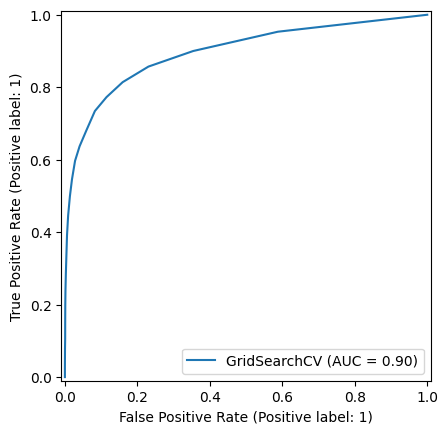

In [ ]:
# ROC Curve - Tuned Model
knn_gscv_roc = RocCurveDisplay.from_estimator(knn_gscv, x_test_scaled, y_test)